In [8]:
# --- Notebook Setup (run once) ---
import sys, subprocess, logging

def pip_install(pkg: str):
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])

# Install missing packages (safe if already installed)
try:
    import fitz  # PyMuPDF
except Exception:
    pip_install("pymupdf")

try:
    import docx  # python-docx
except Exception:
    pip_install("python-docx")

try:
    import transformers
except Exception:
    pip_install("transformers")

logging.basicConfig(level=logging.INFO)
print("✅ Setup complete")

✅ Setup complete


## Document Parser

In [9]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional
from dataclasses import dataclass
import logging

logger = logging.getLogger("policy_parser")


@dataclass
class Document:
    content: str
    metadata: Dict[str, str]
    source: str
    page_numbers: Optional[List[int]] = None


class DocumentParser:
    def __init__(self, header_footer_ratio: float = 0.08):
        self.supported_formats = {".pdf", ".docx", ".txt"}
        self.header_footer_ratio = header_footer_ratio

    def parse(self, file_path: Path) -> Document:
        file_path = Path(file_path)  # allow str/path
        suffix = file_path.suffix.lower()

        if suffix not in self.supported_formats:
            raise ValueError(f"Unsupported format: {suffix}")

        if suffix == ".pdf":
            return self._parse_pdf(file_path)
        if suffix == ".docx":
            return self._parse_docx(file_path)
        return self._parse_txt(file_path)

    def _parse_pdf(self, file_path: Path) -> Document:
        import fitz  # PyMuPDF

        pdf = fitz.open(str(file_path))
        page_count = pdf.page_count

        content_parts: List[str] = []
        page_numbers: List[int] = []

        for page_idx in range(page_count):
            page = pdf[page_idx]
            page_num = page_idx + 1

            blocks = page.get_text("blocks")
            if not blocks:
                continue

            page_h = page.rect.height
            top_cut = page_h * self.header_footer_ratio
            bot_cut = page_h * (1.0 - self.header_footer_ratio)

            filtered = []
            for b in blocks:
                x0, y0, x1, y1, text = b[0], b[1], b[2], b[3], b[4]
                if not text or not text.strip():
                    continue
                if y1 < top_cut or y0 > bot_cut:
                    continue
                filtered.append((x0, y0, x1, y1, text.strip()))

            if not filtered:
                continue

            filtered.sort(key=lambda t: (t[1], t[0]))
            page_text = "\n".join(t[4] for t in filtered)

            content_parts.append(f"[Page {page_num}]\n{page_text}")
            page_numbers.append(page_num)

        metadata = {
            "title": (pdf.metadata or {}).get("title", "") or "",
            "author": (pdf.metadata or {}).get("author", "") or "",
            "pages": str(page_count),
            "format": "pdf",
            "parser": "pymupdf",
        }

        pdf.close()

        logger.info(f"Parsed PDF: {file_path.name}, pages={page_count}, kept_pages={len(page_numbers)}")

        return Document(
            content="\n\n".join(content_parts),
            metadata=metadata,
            source=str(file_path),
            page_numbers=page_numbers,
        )

    def _parse_docx(self, file_path: Path) -> Document:
        from docx import Document as DocxDocument

        docx = DocxDocument(str(file_path))
        parts: List[str] = []

        for p in docx.paragraphs:
            text = (p.text or "").strip()
            if not text:
                continue

            style = (p.style.name or "").lower()
            if style.startswith("heading"):
                parts.append(f"\n## {text}\n")
            else:
                parts.append(text)

        for table in docx.tables:
            parts.append("\n" + self._parse_table(table) + "\n")

        metadata = {
            "title": file_path.stem,
            "paragraphs": str(len(docx.paragraphs)),
            "tables": str(len(docx.tables)),
            "format": "docx",
            "parser": "python-docx",
        }

        logger.info(f"Parsed DOCX: {file_path.name}, paragraphs={len(docx.paragraphs)}, tables={len(docx.tables)}")

        return Document(
            content="\n".join(parts),
            metadata=metadata,
            source=str(file_path),
        )

    def _parse_table(self, table) -> str:
        rows = []
        for row in table.rows:
            cells = [" ".join((cell.text or "").split()) for cell in row.cells]
            rows.append(" | ".join(cells).strip())
        return "\n".join(r for r in rows if r)

    def _parse_txt(self, file_path: Path) -> Document:
        try:
            content = file_path.read_text(encoding="utf-8")
        except UnicodeDecodeError:
            content = file_path.read_text(encoding="utf-8", errors="ignore")

        metadata = {
            "title": file_path.stem,
            "format": "txt",
            "parser": "plaintext",
        }

        logger.info(f"Parsed TXT: {file_path.name}, chars={len(content)}")

        return Document(content=content, metadata=metadata, source=str(file_path))

## Hybrid chunker

In [12]:
from __future__ import annotations

from typing import List, Dict
from dataclasses import dataclass
import re
import logging
from transformers import AutoTokenizer

logger = logging.getLogger("policy_chunker")


@dataclass
class Chunk:
    text: str
    chunk_id: str
    document_id: str
    metadata: Dict
    token_start: int
    token_end: int


class SemanticChunker:
    def __init__(
        self,
        tokenizer_name: str = "sentence-transformers/all-MiniLM-L6-v2",
        chunk_size: int = 512,
        chunk_overlap: int = 64,
        min_chunk_tokens: int = 50,
    ):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.min_chunk_tokens = min_chunk_tokens

        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.sentence_splitter = re.compile(r"(?<=[.!?。！？])\s+")

    def chunk_document(self, text: str, document_id: str, metadata: Dict) -> List[Chunk]:
        sentences = self._split_sentences(text)

        chunks: List[Chunk] = []
        current_sentences: List[str] = []
        current_tokens = 0
        token_cursor = 0

        for sentence in sentences:
            sent_tokens = self._count_tokens(sentence)

            if current_tokens + sent_tokens > self.chunk_size and current_sentences:
                chunk_text = " ".join(current_sentences)
                chunk_token_len = self._count_tokens(chunk_text)

                chunks.append(
                    Chunk(
                        text=chunk_text,
                        chunk_id=f"{document_id}_chunk_{len(chunks)}",
                        document_id=document_id,
                        metadata=metadata,
                        token_start=token_cursor,
                        token_end=token_cursor + chunk_token_len,
                    )
                )

                overlap_text = self._get_overlap(current_sentences)
                overlap_tokens = self._count_tokens(overlap_text) if overlap_text else 0

                current_sentences = [overlap_text] if overlap_text else []
                current_tokens = overlap_tokens
                token_cursor += chunk_token_len - overlap_tokens

            current_sentences.append(sentence)
            current_tokens += sent_tokens

        if current_sentences:
            chunk_text = " ".join(current_sentences)
            token_len = self._count_tokens(chunk_text)

            if token_len >= self.min_chunk_tokens:
                chunks.append(
                    Chunk(
                        text=chunk_text,
                        chunk_id=f"{document_id}_chunk_{len(chunks)}",
                        document_id=document_id,
                        metadata=metadata,
                        token_start=token_cursor,
                        token_end=token_cursor + token_len,
                    )
                )

        logger.info(f"Chunked {document_id}: {len(chunks)} chunks")
        return chunks

    def _split_sentences(self, text: str) -> List[str]:
        sentences = self.sentence_splitter.split(text)
        return [s.strip() for s in sentences if s.strip()]

    def _count_tokens(self, text: str) -> int:
        return len(self.tokenizer.encode(text, add_special_tokens=False))

    def _get_overlap(self, sentences: List[str]) -> str:
        overlap_tokens = 0
        overlap_sentences = []

        for sent in reversed(sentences):
            sent_tokens = self._count_tokens(sent)
            if overlap_tokens + sent_tokens > self.chunk_overlap:
                break
            overlap_sentences.insert(0, sent)
            overlap_tokens += sent_tokens

        return " ".join(overlap_sentences)


class HybridChunker(SemanticChunker):
    def __init__(self, skip_toc: bool = True, **kwargs):
        super().__init__(**kwargs)

        self.skip_toc = skip_toc

        self.header_patterns = [
            re.compile(r"^\d+\.\s+[A-Z]"),      # "1. POLICY"
            re.compile(r"^[A-Z][A-Z\s]{6,}$"),  # "LEAVE POLICY"
            re.compile(r"^##\s+"),              # Markdown headers
        ]

    def chunk_document(self, text: str, document_id: str, metadata: Dict) -> List[Chunk]:
        sections = self._split_sections(text)
        all_chunks: List[Chunk] = []

        for idx, section in enumerate(sections):
            header = (section.get("header") or "").strip()
            header_l = header.lower()

            # ✅ FIX: Skip Table of Contents / Index sections
            if self.skip_toc:
                if ("table of contents" in header_l) or (header_l in {"contents", "index"}):
                    logger.info(f"Skipping TOC section: '{header}'")
                    continue

            section_metadata = {
                **metadata,
                "section_id": idx,
                "section_header": header,
            }

            section_chunks = super().chunk_document(
                text=section["content"],
                document_id=f"{document_id}_sec{idx}",
                metadata=section_metadata,
            )

            all_chunks.extend(section_chunks)

        return all_chunks

    def _split_sections(self, text: str) -> List[Dict]:
        lines = text.splitlines()
        sections = []
        current = {"header": "", "content": ""}

        for line in lines:
            ls = line.strip()
            if any(p.match(ls) for p in self.header_patterns):
                if current["content"].strip():
                    sections.append(current)
                current = {"header": ls, "content": ""}
            else:
                current["content"] += line + "\n"

        if current["content"].strip():
            sections.append(current)

        return sections if sections else [{"header": "", "content": text}]

## Parse + Chunk

In [13]:
from pathlib import Path

PDF_PATH = Path("/content/HR-Guide_-Policy-and-Procedure-Template.pdf")  # change if needed

parser = DocumentParser(header_footer_ratio=0.08)
doc = parser.parse(PDF_PATH)

chunker = HybridChunker(
    tokenizer_name="sentence-transformers/all-MiniLM-L6-v2",
    chunk_size=512,
    chunk_overlap=64,
)

chunks = chunker.chunk_document(
    text=doc.content,
    document_id=Path(doc.source).stem,
    metadata=doc.metadata,
)

print("✅ Parsed:", doc.source)
print("Pages kept:", len(doc.page_numbers or []))
print("Total chars:", len(doc.content))
print("Chunks:", len(chunks))
print("\n--- First chunk preview ---\n")
print(chunks[0].text[:800])
print("\n--- First chunk metadata ---\n")
print(chunks[0].metadata)

✅ Parsed: /content/HR-Guide_-Policy-and-Procedure-Template.pdf
Pages kept: 52
Total chars: 108106
Chunks: 49

--- First chunk preview ---

Health and Safety
26
Fitness for Duty
27
Legislation affecting relationship
42
between employers and employees
SECTION 6
Hiring
in Canada’s provinces and territories
Hiring Process
29
Recruitment
30
Selection
31
Offer of Employment
32
Orientation
33
Probationary Review
34
Performance Appraisals
35

[Page 4]
SECTION 1
Introduction to the Template
and Human Resource Policies
Objectives of the Template
This template is provided as a tool for community foundations to develop policies on all matters related to
conditions of employment. There are parts of this policy which also apply to volunteers and individuals working on
contract. Those policies that do not apply to volunteers and contractors will be so noted at the beginning of each
policy. Employment-related legislation is a provincial resp

--- First chunk metadata ---

{'title': 'HR Guide: Policy a

## Cell E

In [14]:
# --- Embeddings Setup (safe to re-run) ---
import sys, subprocess, logging

def pip_install(pkg: str):
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])

# sentence-transformers is required
try:
    import sentence_transformers
except Exception:
    pip_install("sentence-transformers")

import torch
import numpy as np
from pathlib import Path
from typing import List, Optional
from sentence_transformers import SentenceTransformer

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("policy_embedder")

print("✅ Embedding setup complete")

✅ Embedding setup complete


## Cell F

In [15]:
class MultilingualEmbedder:
    """
    Production embedder for EN/KR policy documents (E5 style).
    - Batch encoding
    - GPU/CPU auto
    - L2-normalized embeddings
    """

    def __init__(
        self,
        model_name: str = "intfloat/multilingual-e5-large",
        device: str = None,
        batch_size: int = 32,
    ):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.batch_size = batch_size

        logger.info(f"Loading embedding model: {model_name}")
        logger.info(f"Device: {self.device}")

        self.model = SentenceTransformer(model_name, device=self.device)
        self.embedding_dim = self.model.get_sentence_embedding_dimension()

        logger.info(f"Model loaded. Embedding dim: {self.embedding_dim}")

    def embed_documents(self, texts: List[str], show_progress: bool = True) -> np.ndarray:
        # E5 best practice: "passage:" prefix for docs
        prefixed = [f"passage: {t}" for t in texts]

        embs = self.model.encode(
            prefixed,
            batch_size=self.batch_size,
            show_progress_bar=show_progress,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )

        logger.info(f"Embedded {len(texts)} documents -> {embs.shape}")
        return embs

    def embed_query(self, query: str) -> np.ndarray:
        # E5 best practice: "query:" prefix for queries
        prefixed = f"query: {query}"

        emb = self.model.encode(
            prefixed,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return emb

    def compute_similarity(self, query_embedding: np.ndarray, document_embeddings: np.ndarray) -> np.ndarray:
        # embeddings are normalized => dot product == cosine similarity
        return document_embeddings @ query_embedding


class EmbeddingCache:
    """Simple disk cache to avoid recomputing embeddings"""

    def __init__(self, cache_dir: str = "./data/embeddings"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def save(self, embeddings: np.ndarray, cache_key: str):
        path = self.cache_dir / f"{cache_key}.npy"
        np.save(path, embeddings)
        logger.info(f"Cached embeddings: {path}")

    def load(self, cache_key: str) -> Optional[np.ndarray]:
        path = self.cache_dir / f"{cache_key}.npy"
        if path.exists():
            embs = np.load(path)
            logger.info(f"Loaded cached embeddings: {path}")
            return embs
        return None

## Cell G

In [16]:
# --- Build embeddings for your chunks (from Cell D) ---

embedder = MultilingualEmbedder(
    model_name="intfloat/multilingual-e5-large",
    batch_size=32,
)

# texts to embed
chunk_texts = [c.text for c in chunks]

# optional cache
cache = EmbeddingCache("./data/embeddings")
cache_key = "hr_policy_chunks_e5_large"

doc_embeddings = cache.load(cache_key)
if doc_embeddings is None:
    doc_embeddings = embedder.embed_documents(chunk_texts, show_progress=True)
    cache.save(doc_embeddings, cache_key)

print("✅ doc_embeddings shape:", doc_embeddings.shape)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ doc_embeddings shape: (49, 1024)


## Cell H

In [17]:
def search(query: str, top_k: int = 5):
    q_emb = embedder.embed_query(query)
    scores = embedder.compute_similarity(q_emb, doc_embeddings)
    top_idx = np.argsort(scores)[::-1][:top_k]

    print(f"\nQUERY: {query}")
    print("-" * 60)
    for rank, i in enumerate(top_idx, start=1):
        meta = chunks[i].metadata
        header = meta.get("section_header", "")
        print(f"[{rank}] score={scores[i]:.4f} | section='{header}' | chunk_id={chunks[i].chunk_id}")
        print(chunks[i].text[:300].replace("\n", " "))
        print()

# English query
search("What is the overtime policy?", top_k=5)

# Korean query
search("연장근무 규정이 어떻게 되나요?", top_k=5)


QUERY: What is the overtime policy?
------------------------------------------------------------
[1] score=0.8324 | section='APPENDIX A' | chunk_id=HR-Guide_-Policy-and-Procedure-Template_sec3_chunk_7
Policy and Procedure Statement Overtime is considered to be anything over 8 hours worked in a day and excess of 44 hours in a week for full-time employees. The Foundation will grant time off for hours worked beyond what would be considered a standard work week. Any hours worked in excess of 8 hours 

[2] score=0.8100 | section='APPENDIX A' | chunk_id=HR-Guide_-Policy-and-Procedure-Template_sec3_chunk_6
The standard workweek is comprised of a maximum of ___________ hours per week. (adjust to align with your Foundation’s current practice) If an employee is required to leave the Foundation during normal working hours, he/she is required to notify co-workers, as well as the ED/CEO All employees at the

[3] score=0.7982 | section='APPENDIX A' | chunk_id=HR-Guide_-Policy-and-Procedure-Template

In [29]:
import re
import numpy as np

STOP_PATTERNS = [
    r"_{3,}",                 # placeholders like ________
    r"\(adjust to align",      # template guidance
]

def ask_en(q, k=5, k_retrieve=30):
    # 1) retrieve more candidates
    s = embedder.compute_similarity(embedder.embed_query(q), doc_embeddings)
    cand = np.argsort(s)[::-1][:k_retrieve]

    ql = q.lower()

    def keyword_bonus(text: str) -> float:
        t = text.lower()
        bonus = 0.0
        # lightweight “topic boosts”
        if "overtime" in ql and "overtime" in t: bonus += 0.03
        if ("annual leave" in ql or "vacation" in ql) and ("vacation" in t or "annual leave" in t): bonus += 0.03
        if "sick" in ql and "sick" in t: bonus += 0.03
        if "holiday" in ql and "holiday" in t: bonus += 0.03
        return bonus

    results = []
    for i in cand:
        txt = chunks[i].text

        # 2) filter obvious template junk
        if any(re.search(p, txt, re.IGNORECASE) for p in STOP_PATTERNS):
            continue

        # 3) re-rank with small keyword bonus
        score = float(s[i]) + keyword_bonus(txt)
        results.append((score, i))

    # fallback if everything filtered
    if not results:
        results = [(float(s[i]), i) for i in cand]

    # 4) top-k final
    top = sorted(results, key=lambda x: x[0], reverse=True)[:k]

    print("\nQ:", q)
    print("-" * 60)
    for r, (score, i) in enumerate(top, 1):
        print(f"[{r}] {score:.4f} | {chunks[i].metadata.get('section_header','')} | {chunks[i].chunk_id}")
        print(chunks[i].text[:250].replace("\n", " "), "\n")

## Reranker

In [30]:

!pip -q install sentence-transformers

from sentence_transformers import CrossEncoder
import numpy as np

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")  # light + strong

In [31]:
def ask_en_rerank(q, k=5, k_retrieve=30):
    # retrieve
    s = embedder.compute_similarity(embedder.embed_query(q), doc_embeddings)
    cand = np.argsort(s)[::-1][:k_retrieve]

    # rerank pairs (query, passage)
    pairs = [(q, chunks[i].text) for i in cand]
    rr_scores = reranker.predict(pairs)

    top = cand[np.argsort(rr_scores)[::-1][:k]]

    print("\nQ:", q)
    print("-" * 60)
    for r, i in enumerate(top, 1):
        print(f"[{r}] rr={rr_scores[list(cand).index(i)]:.4f} | {chunks[i].metadata.get('section_header','')} | {chunks[i].chunk_id}")
        print(chunks[i].text[:250].replace("\n", " "), "\n")

In [27]:
ask_en_rerank("How many weeks of vacation do employees get after one year of service?")
ask_en_rerank("Is overtime compensated with time off or pay?")


Q: How many weeks of vacation do employees get after one year of service?
------------------------------------------------------------
[1] rr=6.3235 | APPENDIX A | HR-Guide_-Policy-and-Procedure-Template_sec3_chunk_16
Vacation should be taken in full during the employment year. Cash payments will not be made in lieu of vacation except upon termination of employment. Vacation Schedule ● After completing one full year of service 2 weeks ● 5 – 10 years continuous ser 

[2] rr=2.6862 | APPENDIX A | HR-Guide_-Policy-and-Procedure-Template_sec3_chunk_15
Part-time employees are entitled to receive $40 per month towards parking or bus pass (upon submission of receipts). Vacation Employees need a break from work every now and then in order to maintain their physical and mental health. A number of studi 

[3] rr=-3.8356 | APPENDIX A | HR-Guide_-Policy-and-Procedure-Template_sec3_chunk_7
Policy and Procedure Statement Overtime is considered to be anything over 8 hours worked in a day and excess 

## Visualizations

Kept chunks: 46 / 49
Eval size: 8 | EN MRR: 1.0 | KO MRR: 0.778


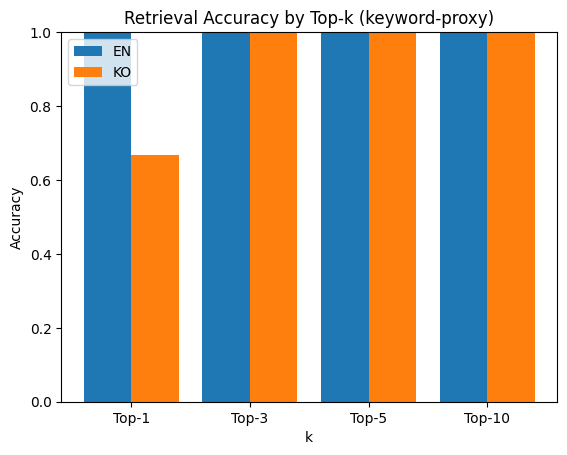

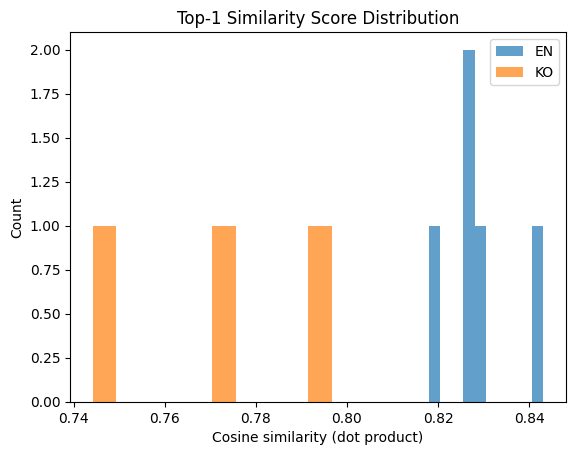

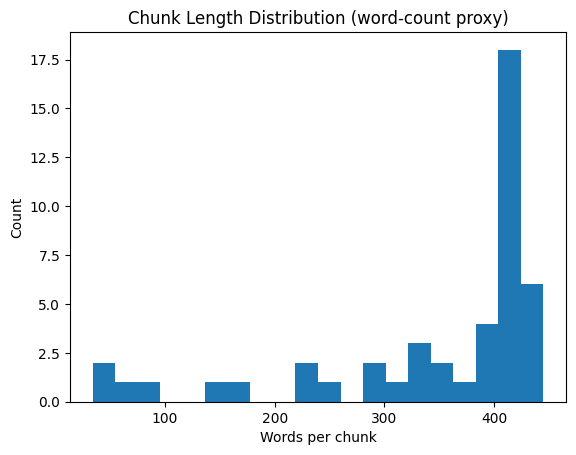

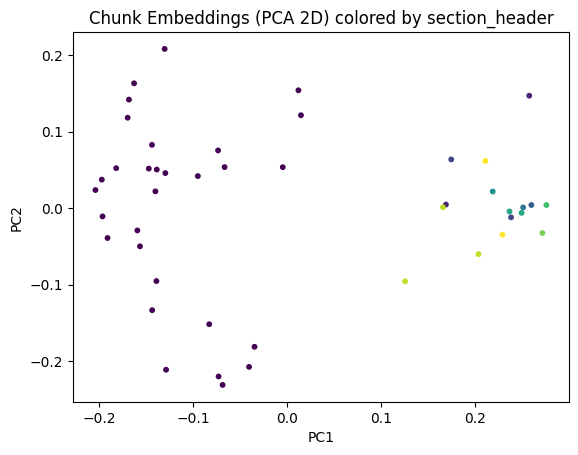

✅ Visualizations generated.


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import re

# --- Guard: make sure required variables exist ---
missing = [name for name in ["chunks", "doc_embeddings", "embedder"] if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables: {missing}\n"
        "Run these first:\n"
        "- Cell D (creates chunks)\n"
        "- Cell G (creates embedder + doc_embeddings)\n"
    )

# -----------------------------
# Helpers: filter low-signal chunks
# -----------------------------
def _is_toc_like(text: str) -> bool:
    tl = text.lower()
    if "table of contents" in tl or tl.strip() in {"contents", "index"}:
        return True
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    if len(lines) >= 8:
        ends_with_num = sum(1 for ln in lines[:20] if ln[-1].isdigit())
        if ends_with_num / min(len(lines), 20) >= 0.5:
            return True
    return False

def _keep_chunk(text: str) -> bool:
    if _is_toc_like(text):
        return False
    if "___" in text:
        return False
    if "(adjust to align" in text.lower():
        return False
    return True

keep_mask = np.array([_keep_chunk(c.text) for c in chunks], dtype=bool)
kept_indices = np.where(keep_mask)[0]

def retrieve(query: str, top_k: int = 5):
    q_emb = embedder.embed_query(query)
    scores = embedder.compute_similarity(q_emb, doc_embeddings)  # (N,)
    scores_kept = scores[kept_indices]
    order = np.argsort(scores_kept)[::-1]
    top_global = kept_indices[order[:top_k]]
    return top_global, scores[top_global]

# -----------------------------
# A tiny evaluation set (edit anytime)
# -----------------------------
eval_queries = [
    {"q": "What is considered overtime?", "must_any": ["overtime"] , "lang": "en"},
    {"q": "When does overtime start per day and per week?", "must_any": ["overtime", "hours"], "lang": "en"},
    {"q": "What is the vacation schedule after one year of service?", "must_any": ["vacation", "weeks"], "lang": "en"},
    {"q": "When is a medical certificate required for sick leave?", "must_any": ["medical", "certificate", "sick"], "lang": "en"},
    {"q": "What statutory holidays are observed?", "must_any": ["holiday"], "lang": "en"},
    {"q": "연장근무는 언제부터 적용되나요?", "must_any": ["overtime", "연장"], "lang": "ko"},
    {"q": "휴가는 1년 근무 후 얼마나 받을 수 있나요?", "must_any": ["vacation", "휴가"], "lang": "ko"},
    {"q": "병가는 언제 진단서가 필요하나요?", "must_any": ["sick", "병가", "진단서"], "lang": "ko"},
]

def hit_any(item, idxs):
    keys = [k.lower() for k in item["must_any"]]
    for i in idxs:
        t = chunks[i].text.lower()
        if any(k in t for k in keys):
            return True
    return False

def mrr_any(item, idxs):
    keys = [k.lower() for k in item["must_any"]]
    for r, i in enumerate(idxs, start=1):
        t = chunks[i].text.lower()
        if any(k in t for k in keys):
            return 1.0 / r
    return 0.0

topk_list = [1, 3, 5, 10]
acc = {"en": [], "ko": []}
mrr = {"en": [], "ko": []}

for item in eval_queries:
    lang = item["lang"]
    top10, _ = retrieve(item["q"], top_k=10)
    mrr[lang].append(mrr_any(item, top10))
    acc_row = []
    for k in topk_list:
        idxs, _ = retrieve(item["q"], top_k=k)
        acc_row.append(1.0 if hit_any(item, idxs) else 0.0)
    acc[lang].append(acc_row)

acc_en = np.mean([row for row in acc["en"]], axis=0) if acc["en"] else np.array([np.nan]*len(topk_list))
acc_ko = np.mean([row for row in acc["ko"]], axis=0) if acc["ko"] else np.array([np.nan]*len(topk_list))
mrr_en = float(np.mean(mrr["en"])) if mrr["en"] else float("nan")
mrr_ko = float(np.mean(mrr["ko"])) if mrr["ko"] else float("nan")

print("Kept chunks:", len(kept_indices), "/", len(chunks))
print("Eval size:", len(eval_queries), "| EN MRR:", round(mrr_en, 3), "| KO MRR:", round(mrr_ko, 3))

# -----------------------------
# Viz 1: Top-k accuracy
# -----------------------------
plt.figure()
x = np.arange(len(topk_list))
plt.bar(x - 0.2, acc_en, width=0.4, label="EN")
plt.bar(x + 0.2, acc_ko, width=0.4, label="KO")
plt.xticks(x, [f"Top-{k}" for k in topk_list])
plt.ylim(0, 1.0)
plt.title("Retrieval Accuracy by Top-k (keyword-proxy)")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------
# Viz 2: Top-1 score distribution
# -----------------------------
en_scores, ko_scores = [], []
for item in eval_queries:
    idxs, sc = retrieve(item["q"], top_k=1)
    if item["lang"] == "en":
        en_scores.append(float(sc[0]))
    else:
        ko_scores.append(float(sc[0]))

plt.figure()
plt.hist(en_scores, bins=10, alpha=0.7, label="EN")
plt.hist(ko_scores, bins=10, alpha=0.7, label="KO")
plt.title("Top-1 Similarity Score Distribution")
plt.xlabel("Cosine similarity (dot product)")
plt.ylabel("Count")
plt.legend()
plt.show()

# -----------------------------
# Viz 3: Chunk length distribution (word proxy)
# -----------------------------
lengths = np.array([len(chunks[i].text.split()) for i in kept_indices], dtype=int)
plt.figure()
plt.hist(lengths, bins=20)
plt.title("Chunk Length Distribution (word-count proxy)")
plt.xlabel("Words per chunk")
plt.ylabel("Count")
plt.show()

# -----------------------------
# Viz 4: 2D embedding visualization (PCA via SVD)
# -----------------------------
X = doc_embeddings[kept_indices]
Xc = X - X.mean(axis=0, keepdims=True)
_, _, Vt = np.linalg.svd(Xc, full_matrices=False)
X2 = Xc @ Vt[:2].T

section_headers = [chunks[i].metadata.get("section_header", "") for i in kept_indices]
label_map = {}
labels = []
for h in section_headers:
    if h not in label_map:
        label_map[h] = len(label_map)
    labels.append(label_map[h])
labels = np.array(labels)

plt.figure()
plt.scatter(X2[:, 0], X2[:, 1], s=10, c=labels)
plt.title("Chunk Embeddings (PCA 2D) colored by section_header")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("✅ Visualizations generated.")